# Design and Implementation of a Fuzzy Logic Controller for Traffic Signal Timing

## Final Project Notebook — Phase 3, Phase 4, Phase 5 & Phase 6

**Course:** Fuzzy Logic & Genetic Programming, GTU (Academic Year 2026–27)  
**Topic:** Traffic Congestion Due to Inefficient Fixed-Time Traffic Signal Control  
**Branch:** Civil Engineering | Semester: V | L.D. College of Engineering, Ahmedabad

### Project objective
Develop a Mamdani-type fuzzy traffic signal controller that determines the required **green-light duration** from two traffic conditions:
- **Queue Length:** 0–50 vehicles
- **Waiting Time:** 0–60 seconds
- **Green Time:** 0–60 seconds

The notebook preserves the Phase 3 fuzzy design and completes the required **Phase 4 Testing, Phase 5 Analysis, RMSE evaluation, and Phase 6 User Interface**.

## 1. Install Required Libraries

Run this cell once. Restart the kernel if Jupyter asks you to after installation.

In [1]:
# %pip install -U scikit-fuzzy scipy matplotlib numpy pandas ipywidgets

## 2. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl
from IPython.display import display

print("Libraries imported successfully.")

ImportError: DLL load failed while importing _voronoi: An Application Control policy has blocked this file.

## 3. Define Input/Output Variables and Membership Functions

The controller uses triangular membership functions for the main control system. The original project also studies trapezoidal and Gaussian membership functions as alternative designs.

In [ ]:
# Universe of discourse
ql_universe = np.arange(0, 51, 1)   # Queue length: 0–50 vehicles
wt_universe = np.arange(0, 61, 1)   # Waiting time: 0–60 seconds
gt_universe = np.arange(0, 61, 1)   # Green time: 0–60 seconds

# Main fuzzy variables
queue_length = ctrl.Antecedent(ql_universe, 'queue_length')
waiting_time = ctrl.Antecedent(wt_universe, 'waiting_time')
green_time = ctrl.Consequent(gt_universe, 'green_time')

# Queue Length membership functions
queue_length['low'] = fuzz.trimf(ql_universe, [0, 10, 25])
queue_length['medium'] = fuzz.trimf(ql_universe, [10, 25, 40])
queue_length['high'] = fuzz.trimf(ql_universe, [25, 40, 50])

# Waiting Time membership functions
waiting_time['short'] = fuzz.trimf(wt_universe, [0, 15, 30])
waiting_time['medium'] = fuzz.trimf(wt_universe, [15, 30, 45])
waiting_time['long'] = fuzz.trimf(wt_universe, [30, 45, 60])

# Green Time membership functions
green_time['short'] = fuzz.trimf(gt_universe, [10, 20, 30])
green_time['medium'] = fuzz.trimf(gt_universe, [20, 35, 50])
green_time['long'] = fuzz.trimf(gt_universe, [40, 50, 60])

print("Main fuzzy variables and membership functions created.")

Main fuzzy variables and membership functions created.


c:\Users\Harsh\OneDrive\Desktop\project\.venv\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


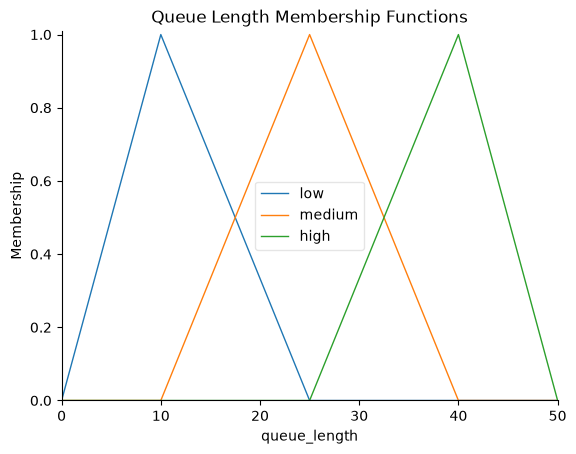

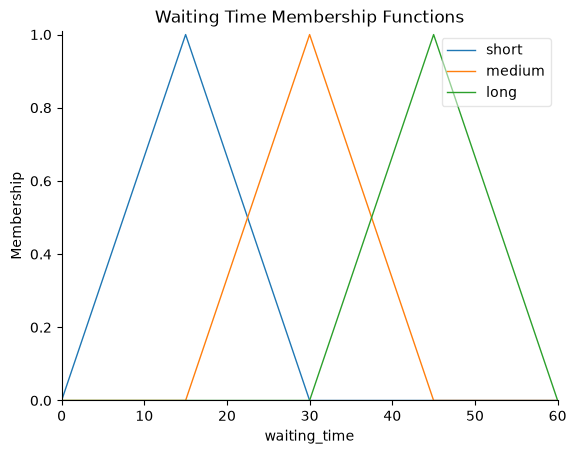

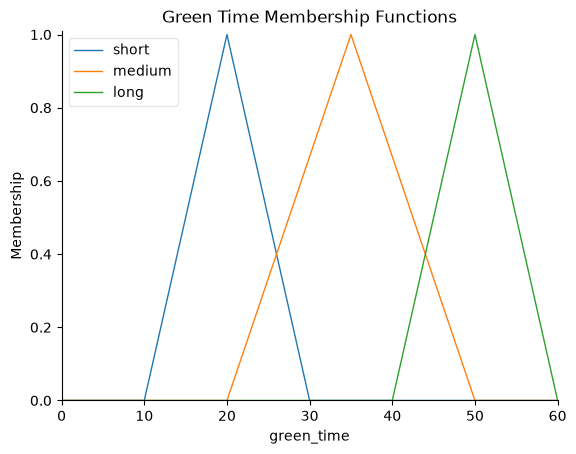

In [ ]:
# Visualize the main membership functions
queue_length.view()
plt.title('Queue Length Membership Functions')
plt.show()

waiting_time.view()
plt.title('Waiting Time Membership Functions')
plt.show()

green_time.view()
plt.title('Green Time Membership Functions')
plt.show()

## 4. Alternative Membership Function Designs

These are retained from Phase 3 for comparison. They are **not** mixed into the main controller.

In [ ]:
# Trapezoidal alternative design
ql_trap = ctrl.Antecedent(ql_universe, 'ql_trap')
wt_trap = ctrl.Antecedent(wt_universe, 'wt_trap')
gt_trap = ctrl.Consequent(gt_universe, 'gt_trap')

ql_trap['low'] = fuzz.trapmf(ql_universe, [0, 0, 10, 25])
ql_trap['medium'] = fuzz.trapmf(ql_universe, [10, 20, 30, 40])
ql_trap['high'] = fuzz.trapmf(ql_universe, [25, 40, 50, 50])

wt_trap['short'] = fuzz.trapmf(wt_universe, [0, 0, 15, 30])
wt_trap['medium'] = fuzz.trapmf(wt_universe, [15, 25, 35, 45])
wt_trap['long'] = fuzz.trapmf(wt_universe, [30, 45, 60, 60])

gt_trap['short'] = fuzz.trapmf(gt_universe, [10, 10, 20, 30])
gt_trap['medium'] = fuzz.trapmf(gt_universe, [20, 30, 40, 50])
gt_trap['long'] = fuzz.trapmf(gt_universe, [40, 50, 60, 60])

# Gaussian alternative design
ql_gaussian = ctrl.Antecedent(ql_universe, 'ql_gaussian')
wt_gaussian = ctrl.Antecedent(wt_universe, 'wt_gaussian')
gt_gaussian = ctrl.Consequent(gt_universe, 'gt_gaussian')

ql_gaussian['low'] = fuzz.gaussmf(ql_universe, 10, 7)
ql_gaussian['medium'] = fuzz.gaussmf(ql_universe, 25, 7)
ql_gaussian['high'] = fuzz.gaussmf(ql_universe, 40, 7)

wt_gaussian['short'] = fuzz.gaussmf(wt_universe, 15, 9)
wt_gaussian['medium'] = fuzz.gaussmf(wt_universe, 30, 9)
wt_gaussian['long'] = fuzz.gaussmf(wt_universe, 45, 9)

gt_gaussian['short'] = fuzz.gaussmf(gt_universe, 20, 7)
gt_gaussian['medium'] = fuzz.gaussmf(gt_universe, 35, 7)
gt_gaussian['long'] = fuzz.gaussmf(gt_universe, 50, 7)

print("Trapezoidal and Gaussian alternatives created separately.")

Trapezoidal and Gaussian alternatives created separately.


## 5. Fuzzy Rule Base

Nine rules map queue length and waiting time to green time. Rule 7 is explicitly included in the controller.

In [ ]:
rule_1 = ctrl.Rule(queue_length['low'] & waiting_time['short'], green_time['short'])
rule_2 = ctrl.Rule(queue_length['low'] & waiting_time['medium'], green_time['short'])
rule_3 = ctrl.Rule(queue_length['low'] & waiting_time['long'], green_time['medium'])
rule_4 = ctrl.Rule(queue_length['medium'] & waiting_time['short'], green_time['medium'])
rule_5 = ctrl.Rule(queue_length['medium'] & waiting_time['medium'], green_time['medium'])
rule_6 = ctrl.Rule(queue_length['medium'] & waiting_time['long'], green_time['long'])
rule_7 = ctrl.Rule(queue_length['high'] & waiting_time['short'], green_time['medium'])
rule_8 = ctrl.Rule(queue_length['high'] & waiting_time['medium'], green_time['long'])
rule_9 = ctrl.Rule(queue_length['high'] & waiting_time['long'], green_time['long'])

rules = [rule_1, rule_2, rule_3, rule_4, rule_5, rule_6, rule_7, rule_8, rule_9]

for i, rule in enumerate(rules, 1):
    print(f"Rule {i}: {rule}")

Rule 1: IF queue_length[low] AND waiting_time[short] THEN green_time[short]
	AND aggregation function : fmin
	OR aggregation function  : fmax
Rule 2: IF queue_length[low] AND waiting_time[medium] THEN green_time[short]
	AND aggregation function : fmin
	OR aggregation function  : fmax
Rule 3: IF queue_length[low] AND waiting_time[long] THEN green_time[medium]
	AND aggregation function : fmin
	OR aggregation function  : fmax
Rule 4: IF queue_length[medium] AND waiting_time[short] THEN green_time[medium]
	AND aggregation function : fmin
	OR aggregation function  : fmax
Rule 5: IF queue_length[medium] AND waiting_time[medium] THEN green_time[medium]
	AND aggregation function : fmin
	OR aggregation function  : fmax
Rule 6: IF queue_length[medium] AND waiting_time[long] THEN green_time[long]
	AND aggregation function : fmin
	OR aggregation function  : fmax
Rule 7: IF queue_length[high] AND waiting_time[short] THEN green_time[medium]
	AND aggregation function : fmin
	OR aggregation function  

## 6. Create the Mamdani Fuzzy Controller

In [ ]:
signal_ctrl = ctrl.ControlSystem(rules)
signal_sim = ctrl.ControlSystemSimulation(signal_ctrl)

print("Fuzzy traffic signal controller created successfully.")

Fuzzy traffic signal controller created successfully.


## 7. Phase 3 — Centroid Defuzzification Example

Centroid is the main defuzzification method used by the project.

Queue Length = 18 vehicles
Waiting Time = 22 seconds
Crisp Green Time = 29.789 seconds


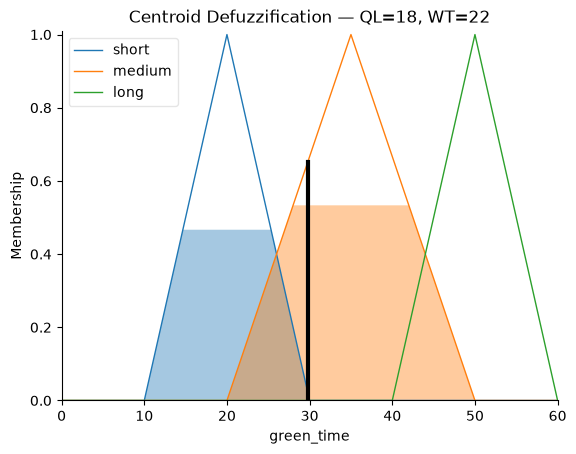

In [ ]:
green_time.defuzzify_method = 'centroid'
signal_sim = ctrl.ControlSystemSimulation(signal_ctrl)
signal_sim.input['queue_length'] = 18
signal_sim.input['waiting_time'] = 22
signal_sim.compute()

print("Queue Length = 18 vehicles")
print("Waiting Time = 22 seconds")
print(f"Crisp Green Time = {signal_sim.output['green_time']:.3f} seconds")

green_time.view(sim=signal_sim)
plt.title('Centroid Defuzzification — QL=18, WT=22')
plt.show()

# PHASE 4 — TESTING

**Requirement:** Test the controller with at least 10 different input combinations and discuss the controller output.

## 8. Phase 4 — Test 12 Input Combinations

The test set covers light, moderate, congested, and severe traffic conditions. Values are kept away from exact zero to avoid a no-rule-firing boundary condition with the triangular membership functions.

In [ ]:
green_time.defuzzify_method = 'centroid'

phase4_test_cases = [
    (2, 3,  'Light traffic'),
    (5, 15,  'Light traffic'),
    (10, 20, 'Moderate traffic'),
    (10, 45, 'High waiting time'),
    (18, 22, 'Moderate traffic'),
    (20, 35, 'Moderate congestion'),
    (25, 30, 'Congestion'),
    (30, 45, 'Heavy congestion'),
    (35, 40, 'Severe congestion'),
    (40, 50, 'Severe congestion'),
    (45, 55, 'Very severe congestion'),
    (48, 55, 'Extreme congestion'),
]

def safe_controller_output(q, w, method='centroid'):
    green_time.defuzzify_method = method
    sim = ctrl.ControlSystemSimulation(signal_ctrl)
    sim.input['queue_length'] = max(float(q), 0.1)
    sim.input['waiting_time'] = max(float(w), 0.1)
    sim.compute()
    if 'green_time' not in sim.output:
        return np.nan
    return float(sim.output['green_time'])

phase4_results = []
for q, w, condition in phase4_test_cases:
    gt = safe_controller_output(q, w, 'centroid')
    phase4_results.append([q, w, condition, gt])

phase4_df = pd.DataFrame(
    phase4_results,
    columns=['Queue Length (veh)', 'Waiting Time (s)', 'Traffic Condition', 'Green Time (s)']
)
phase4_df.index = np.arange(1, len(phase4_df) + 1)
phase4_df.index.name = 'Case'

print(f"Number of test cases: {len(phase4_df)}")
display(phase4_df.round({'Green Time (s)': 3}))

Number of test cases: 12


,Queue Length (veh),Waiting Time (s),Traffic Condition,Green Time (s)
Case,,,,
1,2,3,Light traffic,20.000
2,5,15,Light traffic,20.000
3,10,20,Moderate traffic,20.000
4,10,45,High waiting time,35.000
5,18,22,Moderate traffic,29.789
6,20,35,Moderate congestion,35.000
7,25,30,Congestion,35.000
8,30,45,Heavy congestion,50.000
9,35,40,Severe congestion,42.496


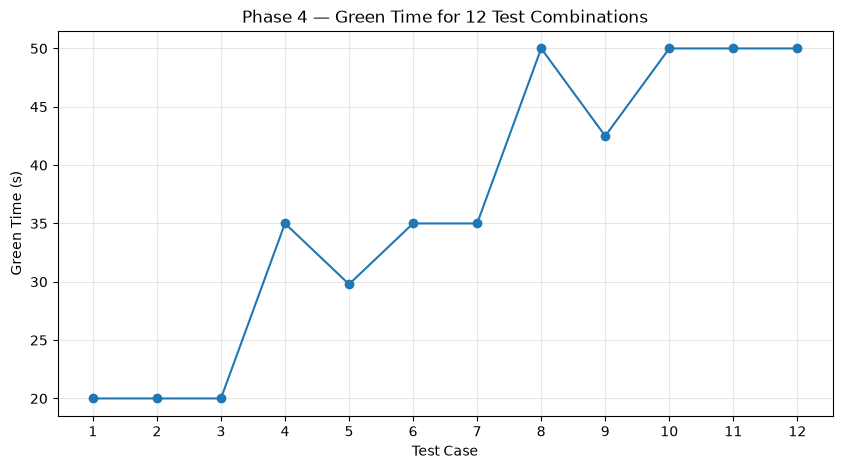

In [ ]:
# Phase 4 output visualization
plt.figure(figsize=(10, 5))
plt.plot(phase4_df.index, phase4_df['Green Time (s)'], marker='o')
plt.xlabel('Test Case')
plt.ylabel('Green Time (s)')
plt.title('Phase 4 — Green Time for 12 Test Combinations')
plt.xticks(phase4_df.index)
plt.grid(True, alpha=0.3)
plt.show()

## 9. Phase 4 — Simulator Screenshots

For the project submission, run the following simulator cells and capture screenshots showing:
1. A light-traffic input and output.
2. A congested-traffic input and output.
3. The Phase 4 results table and graph.

These screenshots provide visual evidence of testing.

In [ ]:
# Screenshot-ready simulator example 1: light traffic
q_demo, w_demo = 5, 15
gt_demo = safe_controller_output(q_demo, w_demo, 'centroid')
print(f"Queue Length = {q_demo} vehicles")
print(f"Waiting Time = {w_demo} seconds")
print(f"Recommended Green Time = {gt_demo:.3f} seconds")

Queue Length = 5 vehicles
Waiting Time = 15 seconds
Recommended Green Time = 20.000 seconds


In [ ]:
# Screenshot-ready simulator example 2: congested traffic
q_demo, w_demo = 40, 50
gt_demo = safe_controller_output(q_demo, w_demo, 'centroid')
print(f"Queue Length = {q_demo} vehicles")
print(f"Waiting Time = {w_demo} seconds")
print(f"Recommended Green Time = {gt_demo:.3f} seconds")

Queue Length = 40 vehicles
Waiting Time = 50 seconds
Recommended Green Time = 50.000 seconds


# PHASE 5 — ANALYSIS

This phase evaluates controller behaviour, monotonicity, defuzzification differences, RMSE, strengths, weaknesses, and possible improvements.

## 10. Phase 5 — Controller Behaviour Analysis

In [ ]:
# Generate a small grid to inspect the controller response
analysis_points = []
for q in [5, 15, 25, 35, 45]:
    for w in [5, 20, 35, 50]:
        gt = safe_controller_output(q, w, 'centroid')
        analysis_points.append([q, w, gt])

analysis_df = pd.DataFrame(
    analysis_points,
    columns=['Queue Length (veh)', 'Waiting Time (s)', 'Green Time (s)']
)
display(analysis_df.round({'Green Time (s)': 3}))

,Queue Length (veh),Waiting Time (s),Green Time (s)
0,5,5,20.000
1,5,20,20.000
2,5,35,28.254
3,5,50,35.000
4,15,5,29.599
5,15,20,27.504
6,15,35,32.350
7,15,50,38.807
8,25,5,35.000
9,25,20,35.000


### Expected behaviour

- Increasing traffic demand should generally lead to a longer green duration.
- Longer waiting time should generally increase priority.
- The fuzzy controller provides gradual changes instead of a single hard threshold.
- The output remains within the defined 0–60 second universe.

## 11. Phase 5 — Monotonicity Checks

Boundary value 0 is replaced by 0.1 during numerical evaluation because the triangular sets can have zero activation exactly at the boundary. This prevents `KeyError: 'green_time'` when no rule fires.

In [ ]:
def monotonicity_check_fixed_wait(wait_value):
    q_values = np.arange(0.1, 51, 5)
    outputs = np.array([safe_controller_output(q, wait_value, 'centroid') for q in q_values])
    valid = outputs[~np.isnan(outputs)]
    passed = np.all(np.diff(valid) >= -1e-9)
    return q_values[:len(valid)], valid, passed

def monotonicity_check_fixed_queue(queue_value):
    w_values = np.arange(0.1, 61, 5)
    outputs = np.array([safe_controller_output(queue_value, w, 'centroid') for w in w_values])
    valid = outputs[~np.isnan(outputs)]
    passed = np.all(np.diff(valid) >= -1e-9)
    return w_values[:len(valid)], valid, passed

queue_non_decreasing = True
wait_non_decreasing = True

print("QUEUE-LENGTH RESPONSE")
print("=" * 50)
for w in [5, 20, 35, 50]:
    _, vals, passed = monotonicity_check_fixed_wait(w)
    queue_non_decreasing &= passed
    print(f"Waiting Time = {w:>2} s : {'PASS' if passed else 'FAIL'}")

print("\nWAITING-TIME RESPONSE")
print("=" * 50)
for q in [5, 20, 35, 50]:
    _, vals, passed = monotonicity_check_fixed_queue(q)
    wait_non_decreasing &= passed
    print(f"Queue Length = {q:>2} vehicles : {'PASS' if passed else 'FAIL'}")

print("\nOverall queue-length response non-decreasing:", queue_non_decreasing)
print("Overall waiting-time response non-decreasing:", wait_non_decreasing)

QUEUE-LENGTH RESPONSE
Waiting Time =  5 s : PASS
Waiting Time = 20 s : FAIL
Waiting Time = 35 s : FAIL
Waiting Time = 50 s : PASS

WAITING-TIME RESPONSE
Queue Length =  5 vehicles : PASS
Queue Length = 20 vehicles : FAIL
Queue Length = 35 vehicles : FAIL
Queue Length = 50 vehicles : PASS

Overall queue-length response non-decreasing: False
Overall waiting-time response non-decreasing: False


## 12. Phase 5 — Output Surface

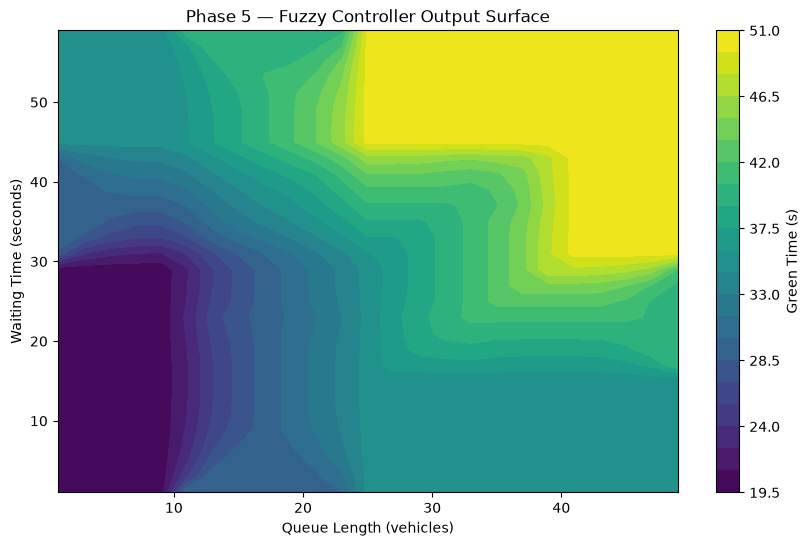

In [ ]:
# Evaluate a grid of queue length and waiting time values
q_grid = np.arange(1, 51, 2)
w_grid = np.arange(1, 61, 2)
Z = np.zeros((len(w_grid), len(q_grid)))

for i, w in enumerate(w_grid):
    for j, q in enumerate(q_grid):
        Z[i, j] = safe_controller_output(q, w, 'centroid')

plt.figure(figsize=(10, 6))
plt.contourf(q_grid, w_grid, Z, levels=20)
plt.colorbar(label='Green Time (s)')
plt.xlabel('Queue Length (vehicles)')
plt.ylabel('Waiting Time (seconds)')
plt.title('Phase 5 — Fuzzy Controller Output Surface')
plt.show()

## 13. Phase 5 — Defuzzification Comparison

In [ ]:
comparison_cases = [(5, 15), (18, 22), (25, 30), (35, 40), (45, 50), (48, 55)]
methods = ['centroid', 'bisector', 'mom', 'som', 'lom']

comparison_rows = []
for q, w in comparison_cases:
    row = {'Queue Length': q, 'Waiting Time': w}
    for method in methods:
        row[method] = safe_controller_output(q, w, method)
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df.round(3))

# Restore the project's primary method
green_time.defuzzify_method = 'centroid' if False else 'centroid'

,Queue Length,Waiting Time,centroid,bisector,mom,som,lom
0,5,15,20.000,20.000,20.0,15.0,25.0
1,18,22,29.789,30.167,35.0,28.0,42.0
2,25,30,35.000,35.000,35.0,35.0,35.0
3,35,40,42.496,44.989,50.0,47.0,53.0
4,45,50,50.000,50.000,50.0,45.0,55.0
5,48,55,50.000,50.000,50.0,42.0,58.0


## 14. Phase 5 — Root Mean Square Error (RMSE) Analysis

### Important interpretation

The notebook does **not** contain real measured green-time targets. Therefore, RMSE here is a **relative comparison of alternative defuzzification methods against the project's selected Centroid method**. It must not be described as real-world prediction accuracy.

,Defuzzification Method,MSE (s^2),RMSE (s)
0,centroid,0.0000,0.0000
1,bisector,1.0598,1.0294
2,mom,13.9108,3.7297
3,som,22.9152,4.7870
4,lom,62.2398,7.8892


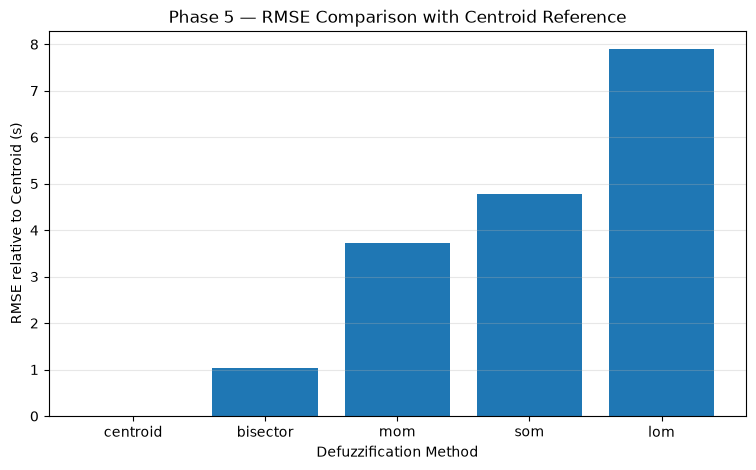

Centroid restored as the primary defuzzification method.


In [ ]:
# Calculate MSE and RMSE relative to Centroid
reference = comparison_df['centroid']
rmse_rows = []

for method in methods:
    errors = comparison_df[method] - reference
    mse = np.mean(errors ** 2)
    rmse = np.sqrt(mse)
    rmse_rows.append([method, mse, rmse])

rmse_df = pd.DataFrame(
    rmse_rows,
    columns=['Defuzzification Method', 'MSE (s^2)', 'RMSE (s)']
)

display(rmse_df.round(4))

plt.figure(figsize=(9, 5))
plt.bar(rmse_df['Defuzzification Method'], rmse_df['RMSE (s)'])
plt.xlabel('Defuzzification Method')
plt.ylabel('RMSE relative to Centroid (s)')
plt.title('Phase 5 — RMSE Comparison with Centroid Reference')
plt.grid(axis='y', alpha=0.3)
plt.show()

green_time.defuzzify_method = 'centroid'
print("Centroid restored as the primary defuzzification method.")

## 15. Phase 5 — Strengths, Weaknesses and Scope of Improvement

### Strengths
1. Uses both queue length and waiting time instead of a single fixed threshold.
2. Produces gradual, flexible green-time decisions.
3. Uses a transparent nine-rule Mamdani rule base.
4. Supports multiple defuzzification methods for comparison.
5. The controller can be tested over a wide range of traffic conditions.

### Weaknesses / limitations
1. Membership-function boundaries are manually selected.
2. The rule base is designed from assumptions rather than calibrated from field data.
3. No real-time traffic sensor stream is included in this notebook.
4. RMSE is relative to Centroid, not to measured real-world green times.
5. The current model considers one signal decision and does not model a complete multi-intersection network.

### Scope of improvement
- Calibrate membership functions using historical traffic data.
- Connect real-time vehicle-count and waiting-time sensors.
- Add lane occupancy, arrival rate, pedestrian demand, and emergency-vehicle priority.
- Compare controller performance against a fixed-time controller using measured delay and queue reduction.
- Use simulation tools such as SUMO for larger traffic-network validation.

# PHASE 6 — USER INTERFACE

Convert the fuzzy controller into a simple interactive interface that allows a user to enter traffic conditions and obtain the recommended green time.

## 16. Phase 6 — Interactive Traffic Signal Controller

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

queue_slider = widgets.IntSlider(
    value=18, min=1, max=50, step=1,
    description='Queue:', continuous_update=False,
    style={'description_width': 'initial'}
)

wait_slider = widgets.IntSlider(
    value=22, min=1, max=60, step=1,
    description='Waiting:', continuous_update=False,
    style={'description_width': 'initial'}
)

method_dropdown = widgets.Dropdown(
    options=['centroid', 'bisector', 'mom', 'som', 'lom'],
    value='centroid',
    description='Method:',
    style={'description_width': 'initial'}
)

calculate_button = widgets.Button(
    description='Calculate Green Time',
    button_style='primary'
)

output_area = widgets.Output()

def classify_traffic(q, w):
    if q <= 10 and w <= 20:
        return 'Light traffic'
    elif q <= 25 and w <= 35:
        return 'Moderate traffic'
    elif q <= 40 and w <= 50:
        return 'Heavy congestion'
    return 'Severe congestion'

def calculate_green_time(_):
    with output_area:
        clear_output(wait=True)
        q = queue_slider.value
        w = wait_slider.value
        method = method_dropdown.value
        gt = safe_controller_output(q, w, method)
        condition = classify_traffic(q, w)

        print("TRAFFIC FUZZY CONTROLLER")
        print("=" * 40)
        print(f"Queue Length   : {q} vehicles")
        print(f"Waiting Time   : {w} seconds")
        print(f"Traffic Status : {condition}")
        print(f"Method         : {method.upper()}")
        print(f"Recommended Green Time : {gt:.2f} seconds")

        # Show the fuzzy output membership result for the selected case
        sim = ctrl.ControlSystemSimulation(signal_ctrl)
        sim.input['queue_length'] = q
        sim.input['waiting_time'] = w
        sim.compute()
        green_time.view(sim=sim)
        plt.title(f'Fuzzy Output — QL={q}, WT={w}, {method.upper()}')
        plt.show()

calculate_button.on_click(calculate_green_time)

ui = widgets.VBox([
    widgets.HTML('<h3>Fuzzy Traffic Signal Controller</h3>'),
    queue_slider,
    wait_slider,
    method_dropdown,
    calculate_button,
    output_area
])

display(ui)

# Initialize output once
calculate_green_time(None)

## 17. Phase 6 — UI Notes

**Inputs:** Queue Length and Waiting Time.  
**Processing:** Mamdani fuzzy inference using the nine project rules.  
**Output:** Recommended Green Time.  
**Defuzzification:** User can compare Centroid, Bisector, MOM, SOM, and LOM.

For the final submission, take a screenshot of the working UI with one light/moderate case and one congested case.

# 18. Final Project Summary

The completed notebook implements the fuzzy traffic signal controller from Phase 3 and extends it through the required Phase 4–6 work:

- **Phase 4:** 12 input combinations, output table, graphs, and screenshot-ready tests.
- **Phase 5:** controller behaviour analysis, monotonicity checks, output surface, defuzzification comparison, RMSE/MSE analysis, strengths, weaknesses, and future improvements.
- **Phase 6:** interactive Jupyter user interface with input controls and recommended green time.

The selected **Centroid** method remains the primary method, while the other defuzzification methods are used for comparison.